# Raw result analysis (original dataset from the paper)

In [1]:
!pwd

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from analysis import load_experiment_data, plot_general_accuracy, plot_intervention_success_rate, calculate_clique_sizes


/home/vic/files/GenMod/Interchange/analysis/result_analysis


In [2]:
RESULTS_DIR = "../results_mqnli"

df = load_experiment_data(RESULTS_DIR)

# look at the (unique) abstract variables and layers we loaded
print("High nodes (abstract variables):", df['high_node'].unique())
print("Low nodes (neural layers):", df['low_node'].unique())

Loaded 9752176 total intervention experiments.
High nodes (abstract variables): <StringArray>
['sentence_q',       'negp',   'obj_noun',      'v_adv',   'subj_adj',
        'neg',        'obj',       'vp_q',       'subj',      'v_bar',
    'obj_adj',         'vp',  'subj_noun',     'v_verb']
Length: 14, dtype: str
Low nodes (neural layers): <StringArray>
[ 'bert_layer_0',  'bert_layer_1', 'bert_layer_10',  'bert_layer_5',
  'bert_layer_6',  'bert_layer_9',  'bert_layer_8',  'bert_layer_3',
  'bert_layer_7',  'bert_layer_2',  'bert_layer_4']
Length: 11, dtype: str


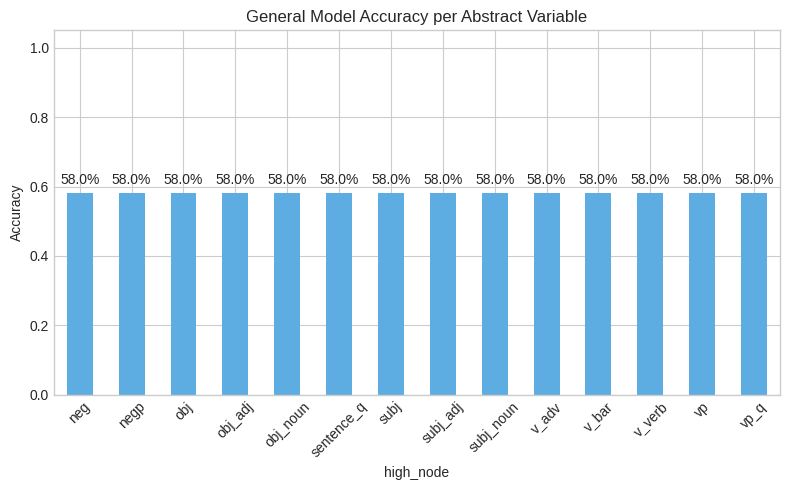

In [3]:
plot_general_accuracy(df, "mqnli")

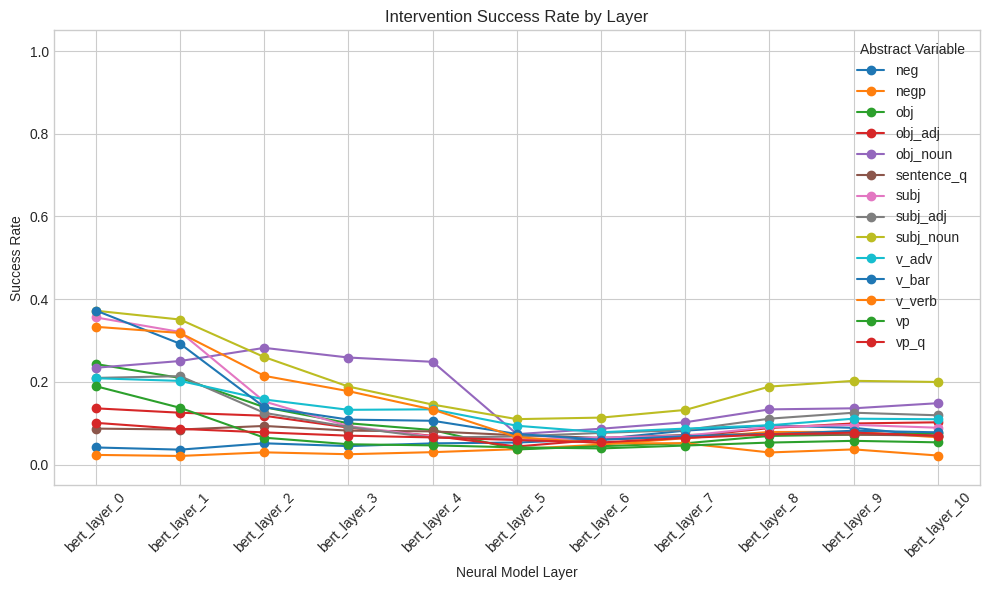

In [4]:

plot_intervention_success_rate(df, "mqnli")

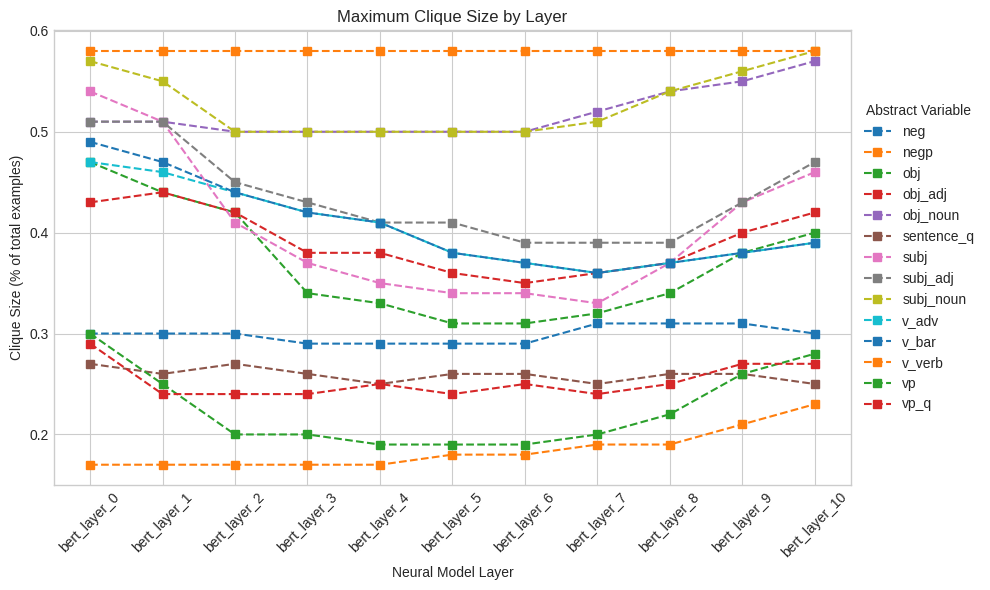

In [5]:

def plot_clique_sizes(df,):
    clique_df = calculate_clique_sizes(df)
    
    clique_pivot = clique_df.pivot(index='high_node', columns='low_node', values='clique_percentage')
    
    # sort columns
    sorted_columns = sorted(clique_pivot.columns, key=lambda x: int(x.split('_')[-1]))
    clique_pivot = clique_pivot[sorted_columns]
    clique_pivot.to_csv('clique_sizes_pivoted_mqnli.csv')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for high_node in clique_pivot.index:
        ax.plot(clique_pivot.columns, clique_pivot.loc[high_node], marker='s', linestyle='--', label=high_node)
        
    ax.set_title("Maximum Clique Size by Layer")
    ax.set_ylabel("Clique Size (% of total examples)")
    ax.set_xlabel("Neural Model Layer")
    # change location to outside of plot
    ax.legend(title="Abstract Variable", loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_clique_sizes(df)